# Galaxy Clustering Using Unsupervised Learning

### Objective and Purpose

#### My aim (or *goal*, if we want to exhaust all synonyms here) is to assess whether a clustering machine learning algorithm can group the GALFIT morphological properties of galaxies into physically meaningful subclasses. 

#### Additionally, I would like to explore alternate approaches to measuring the various environmental effects on galaxies in and surrounding the Virgo cluster. One such approach could well be the creation of k Feature Groups using k-means clustering on galaxy morphologies and determining whether certain groups with certain morphologies are more often found in certain environments.

---

#### Why use ML?

##### Galaxies are a entangled bundle of correlated properties, including morphology, star formation, stellar mass, and environment. Complicating matters, each of these properties is a continuous quantity that does not immediately lend itself to discrete categories.

##### k-means clustering is one approach to evaluating where the data suggest those category bounds exist in morphological space for the sample, as well as what additional properties correlate with each group.

##### Unsupervised machine learning, furthermore, identifies these bounds without enforced assumptions beyond the value of k. 

---

#### Data Credits...

##### The galaxy data are taken from the Virgo Filament Survey (VFS; Castignani+2022), a set of catalogs spanning nearly 7000 galaxies in and surrounding the Virgo Cluster. The GALFIT parameters are specifically from the fourth installment of the VFS paper series (Conger+2025).

##### Photometric data are courtesy of the Legacy Survey (www.legacysurvey.org).

##### I generate the star formation rates and stellar masses using an open source, python-based SED fitting tool called CIGALE (https://cigale.lam.fr/).
 
#####

---

### Step Zero: Import ALL of the relevant python modules

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
#here we go.
import numpy as np
import pandas as pd
import seaborn as sns

from astropy.table import Table
from matplotlib import pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (mean_squared_error, r2_score, accuracy_score, f1_score, 
                             classification_report, confusion_matrix)
from sklearn.model_selection import cross_val_score, train_test_split

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

#from galfit_kmeans import galfit_kmeans
from kmeans_pipeline import run_kmeans

import os
homedir=os.getenv("HOME")

import sys
sys.path.insert(0,'utils')
sys.path.insert(0,'stability_tests')

from clustering_utils import run1_kmeans
from ARI_test import ari_across_seeds
from RFC_test import run_rfc_comparison

### Step One: Defining the Sample and Features

#### As mentioned above, the data all originate from the VFS catalogs: stellar masses, star formation rates, GALFIT parameters, environment classifications, and photometric properties. I specifically use the following GALFIT parameters as the input features for the ML model:

* Effective Radius (kpc) -- W1, W2, W3; r-band, g-band
* Sersic Index (unitless) -- W1, W2, W3; r-band, g-band

##### Effective radius, given by GALFIT in *pixels* but then converted to the more physically meaningful kpc by yours truly, is the radius which encloses 50% of the galaxy's total light. As such, it is also referred to as the half-light radius. If more of the galaxy's light is concentrated in its center, the effective radius will be smaller.

##### Sersic index is a float which, for GALFIT models, spans anywhere from ~1 to the severely unphysical 20. Objects with a higher Sersic index tend to be peakier in the center with a more extended light profile (more elliptical), while lower Sersic indices indicate the galaxy is less peaky in the center and reaches total luminosity more quickly (more disk-like). 

##### W1-3 are three of the four near-infrared channels from the WISE satellite and trace the obscured star formation and spatial extent of the dust in galaxy disks. r- and g-band, meanwhile, are optical 'red' and 'green' from the Legacy Survey and probe the spatial distribution of the stars. In tandem, these features provide a relevant view of the galaxy's morphology.

#### I impose the following "input feature" cuts to the VFS sample:
* GALFIT models must both not have a numerical error and not have failed to run entirely
* nser < 6 [though the numerical error filter also reliably vets most > 6 objects, an unphysical nser regime for galaxies]

#### When evaluating whether certain galaxy properties correlate with the resultant k feature groups, I must make sure that all galaxies in these feature groups have data entries for these properties. More specifically, the galaxies must all have photometric magnitudes (NUV, r-band, W1, W3). Summarizing,

* galaxies MUST have NUV, r, W1, W3 magnitude measurements

##### NUV-r measures the amount of unobscured star formation in a galaxy by comparing its young (NUV) vs. old (r-band) stellar populations. Lower values mean younger stars (more recent star formation), lower values mean the stars are generally older (quenched star formation).

##### W1-W3 measures the dustiness of a galaxy. A higher value means more dusty, a lower values means its infrared color is more so a product of direct stellar emission.

---

### Step Two: K-means Clustering

#### K-means is an unsupervised machine learning algorithm which partitions data into k feature groups in N-dimensional space, where N is the number of input features. 

#### 

NOTE: be sure to edit galfit_parameters.py so parameters are to your liking!

USING THESE FEATURES: ['CRE_g', 'CRE_r', 'CRE_W1-fixBA', 'CRE_W2', 'CRE_W3-fixBA', 'CN_g', 'CN_r', 'CN_W1-fixBA', 
'CN_W2', 'CN_W3-fixBA']

Applying the following completeness limits: logMstar > 8.06, logSFR > -3.065
###################################################################################
Removed 5357/6780 galaxies with GALFIT, completeness limit, and PHOT quality flags.
###################################################################################
IQR clipping (k=1.5): Removing an additional 376/1423 outliers (26.4%)
Remaining galaxies: 1047


A copy of unscaled/scaled galaxy features was written to data/kmeans_feature_data.csv!

#######################################################
Using default feature list for feature raincloud plots:
['Size Ratio', 'NUV_r', 'W1_W3']
#######################################################
#######################################
Incoming...expect an output of 3 plots.
#######################################


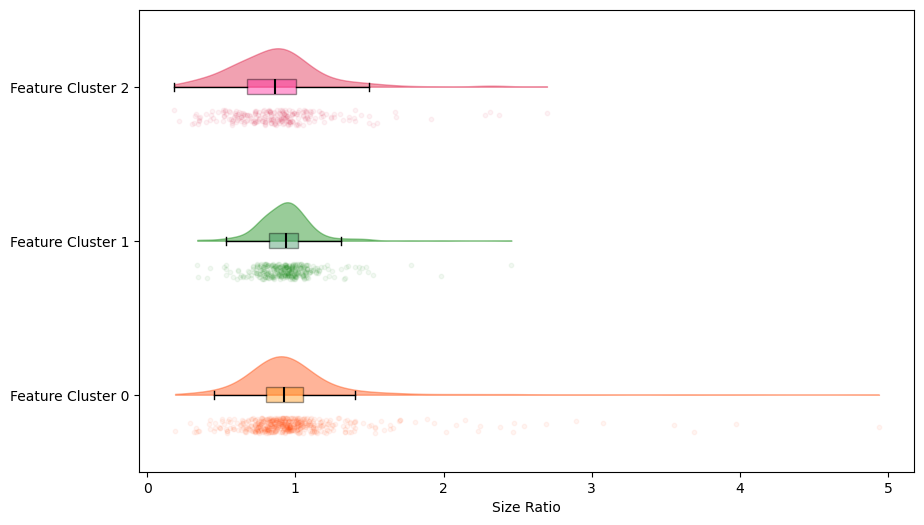

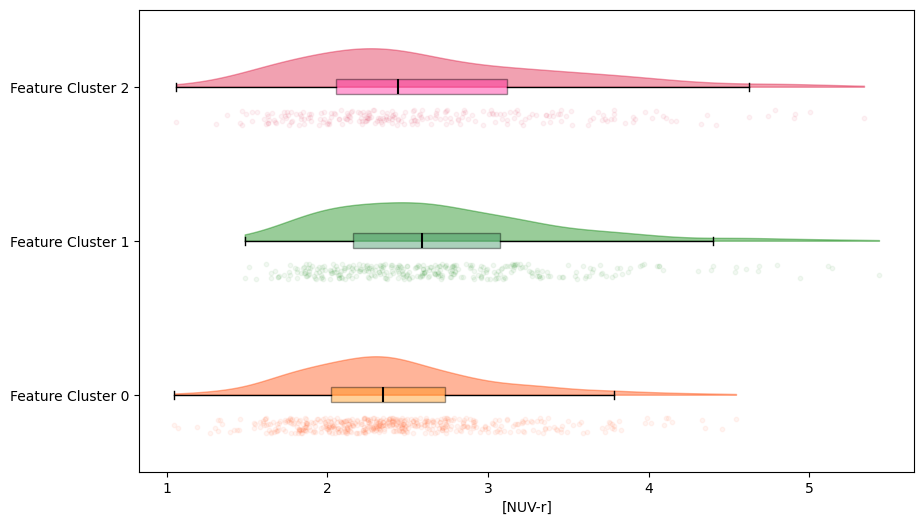

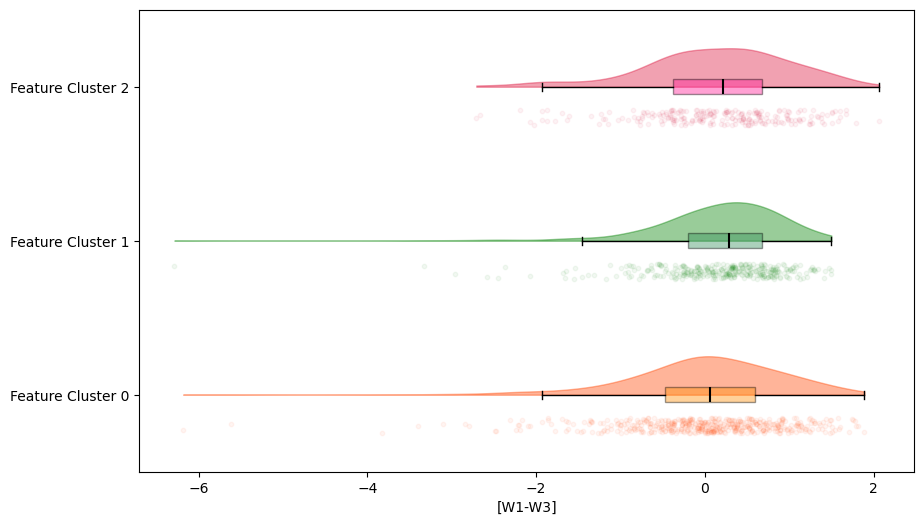

A summary of feature cluster median properties saved to 
/Users/k215c316/github/machine-learning/galaxy_feature_clustering/data/kmeans_median_features.csv:

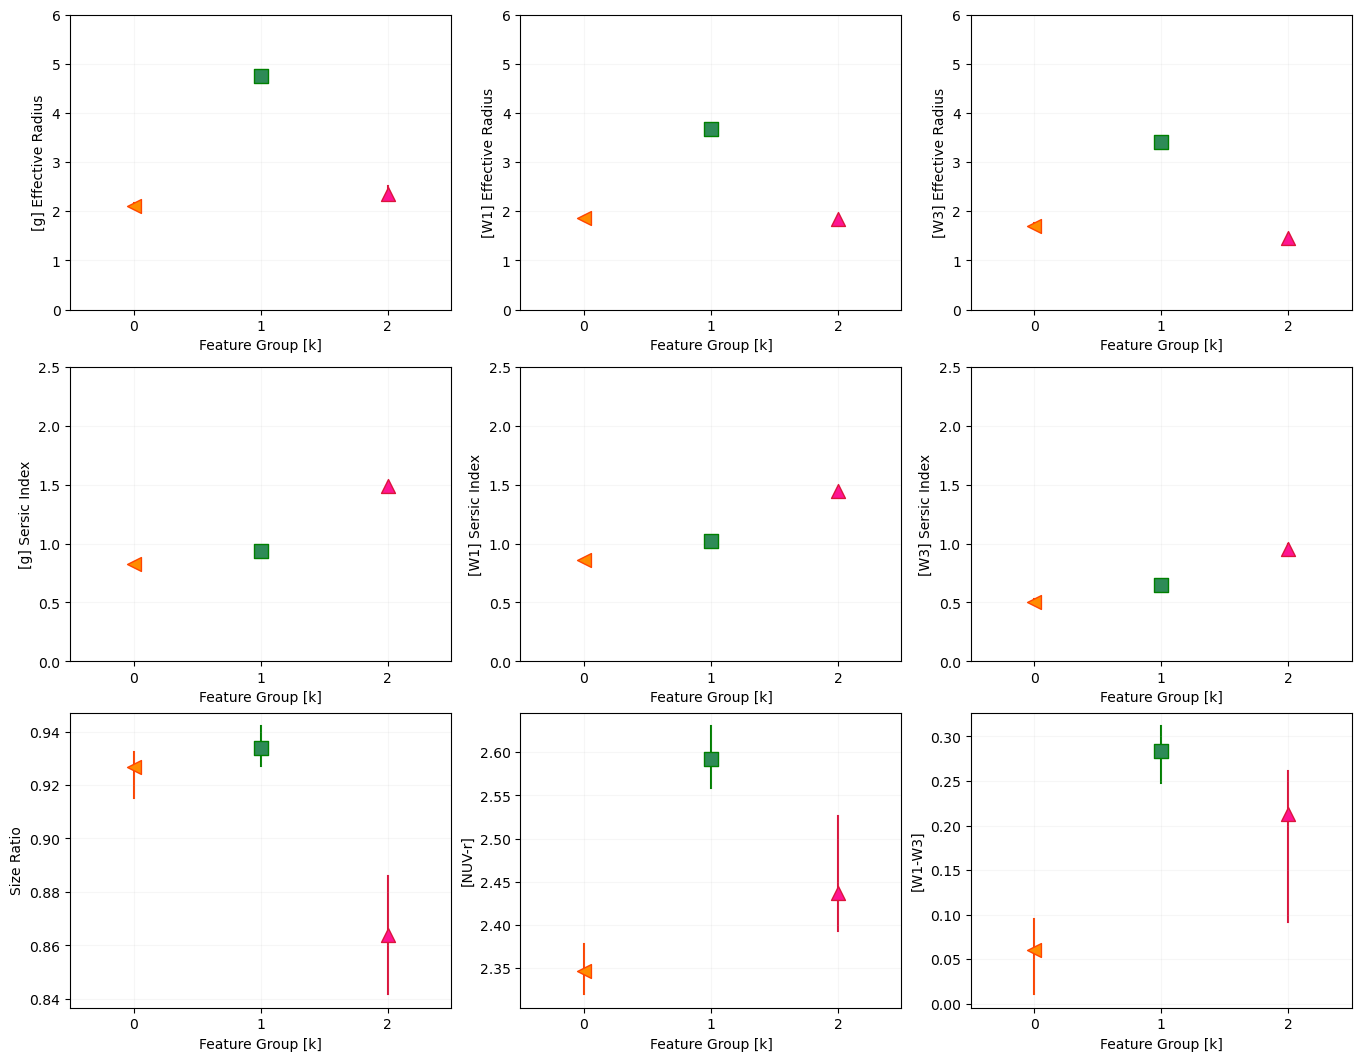

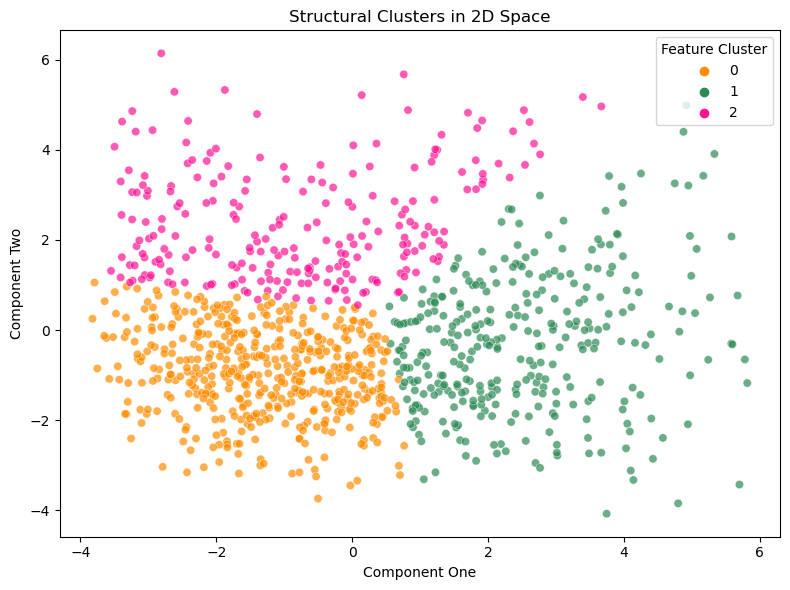

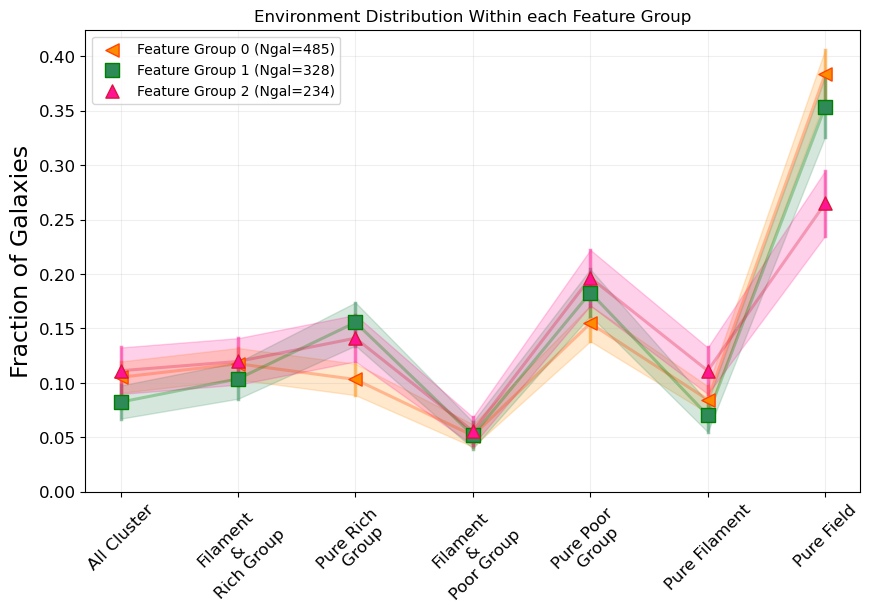

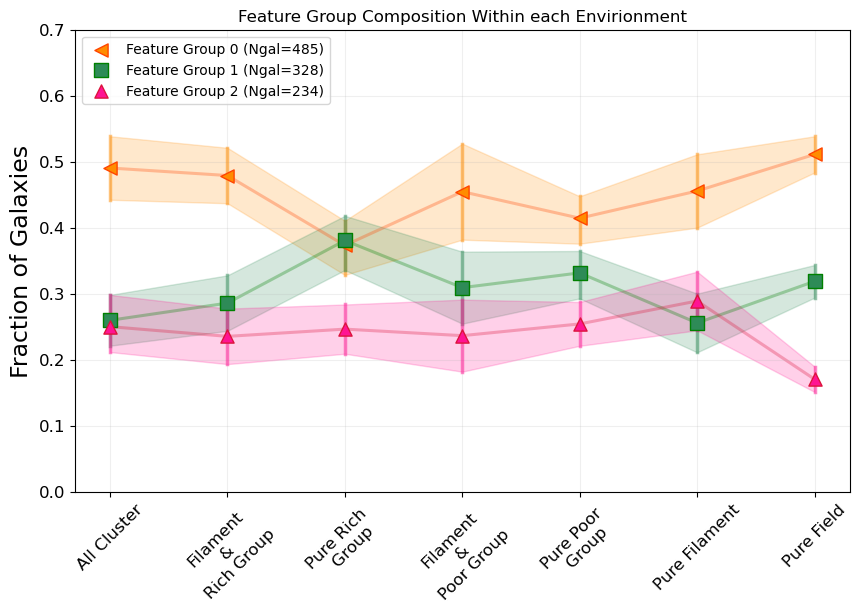

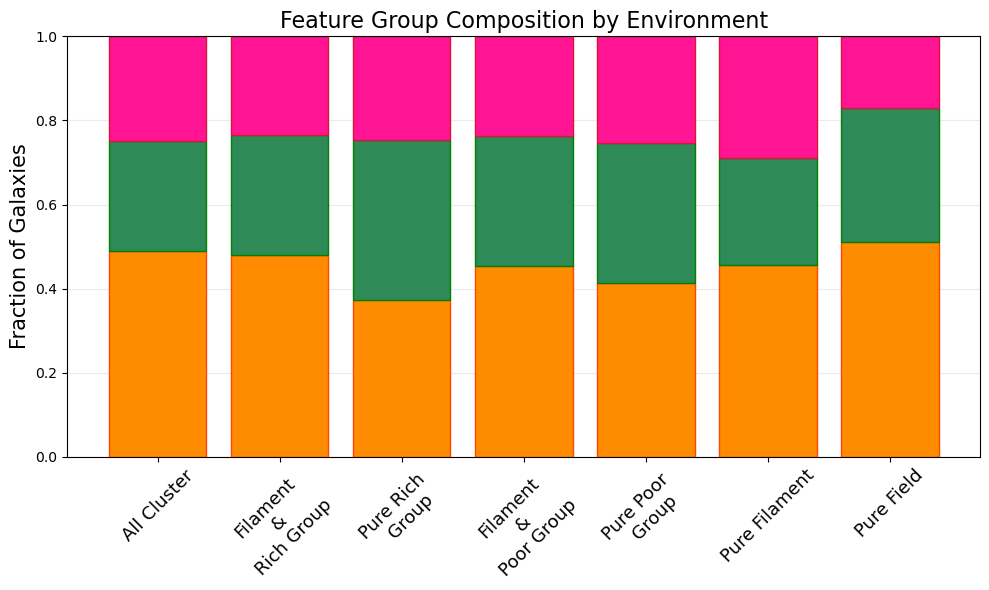

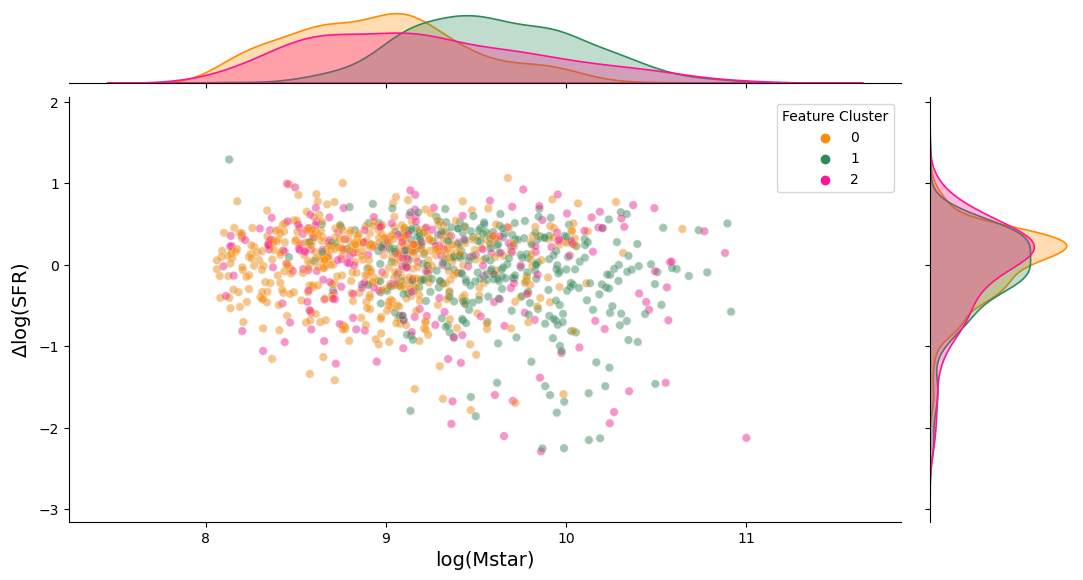

In [3]:
df = run_kmeans(colors=False)

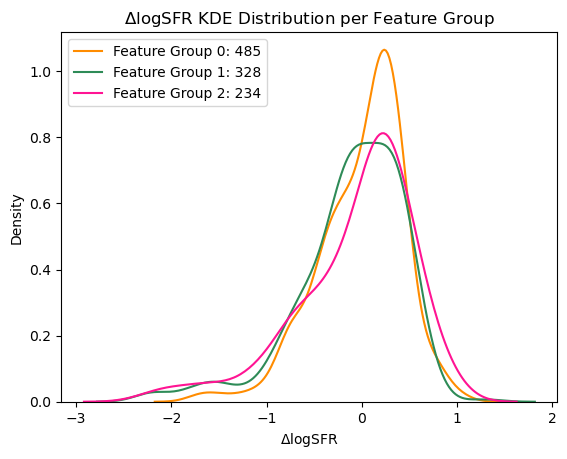

--------------------
ks stat (FG0 & FG1): 0.11247799849132512
p-value (FG0 & FG1): 0.012794497462791106
--------------------
--------------------
ks stat (FG0 & FG2): 0.0939377918759362
p-value (FG0 & FG2): 0.113800765131158
--------------------
--------------------
ks stat (FG1 & FG2): 0.12317594329789451
p-value (FG1 & FG2): 0.028463972720026296
--------------------


In [4]:
from plotting_utils import plot_dSFR_KDEs
plot_dSFR_KDEs(df)

## Measuring the Robustness of K-means Feature Groups [k=3]

This next section is more of a diagnostic test of the robustness of the feature groups. With an independent machine learning algorithm, are the three Feature Groups reproducible? In particular, can a Random Forest Classification model predict the same Feature Group a galaxy that k-means clustering assigned?

My approach first involved creating a train (60% of the sample) and test (40% of the sample) set of the same input features as with k-means. I use the same dataframe as the k-means script output, to ensure sample consistency and the ensure I have the column of Feature Clusters. 

In [30]:
#NO DIFFERENCE BETWEEN SCALED AND UNSCALED PARAMETERS FOR RANDOM FOREST CLASSIFICATION!
#output from k-means run is "df"

#define the x (feature_list) and y (feature_clusters) variable names
feature_list = ['CRE_g', 'CRE_r','CRE_W1-fixBA','CRE_W3-fixBA',
                  'CN_g', 'CN_r', 'CN_W1-fixBA', 'CN_W3-fixBA']
feature_clusters = ['Feature Cluster']

#define the actual X and y sets. also include the galaxy IDs for visual inspection later on.
#(without VFID, how will I know which galaxy is which?)
#also need the PCA components for plotting the clusters...also later on.
X = df[feature_list]
y = df['Feature Cluster']
VFID = df['VFID']
pcacomp1, pcacomp2 = df['Comp1'], df['Comp2']

In [31]:
#define the training and test sets
#I use 60% of the sample for training and 40% for testing
#random_state ensures reproducibility. can set to any positive integer.
X_train, X_test, y_train, y_test, VFID_train, VFID_test= train_test_split(X, y, VFID,
                                                                          test_size=0.4, 
                                                                          random_state=1, 
                                                                          stratify=y)

Next, I set up the Random Forest Classification model scaffold with the following hyperparameters: 

* n_estimators: the number of decision trees used to create the forest 
* max_depth: dictates maximum complexity (i.e., number of splits) for a decision tree 
* class_weight: quite simply, how the model weighs each class. 'Balanced' automatically assigns weights to each class inversely proportional to their frequency in the data, ensuring the minority class gets more attention.
* max_features: size of the random subsets of features to consider for every decision split (sqrt = sqrt(total number of features) 

I then fit the model to the training data and use the result to predict the Feature Groups (classes) of the test dataset.

In [32]:
#model scaffold
model = RandomForestClassifier(n_estimators=10, max_depth=14,class_weight='balanced',
                               random_state=4,max_features='sqrt')

In [33]:
#train the model...
model.fit(X_train, y_train)

,n_estimators,10
,criterion,'gini'
,max_depth,14
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [34]:
#predict Feature Groups (classes) of test dataset
y_pred = model.predict(X_test)

Now that we have our predictions, we can perform some diagnostics. The first is accuracy, which is merely a percentage of the number of correct predictions.

In [35]:
accuracy = (np.sum(np.diag(confusion_matrix(y_test, y_pred)))) / (np.sum(confusion_matrix(y_test, y_pred))) 
print(f'Accuracy: {accuracy*100:.2f}%')

Accuracy: 96.38%


~92% is quite high! Let's try to decompose this score to see where the model hiccuped.

Below is a "classification report," detailing the "precision," "recall," and "f1-score" for each of the three Feature Groups (0, 1, 2). Concentrating on the columns for the moment, using Feature Group 2 (FC2) as an example,

* Precision: when the model predicts FC2, how often is it correct?
* Recall: how many of the k-means FC2 galaxies were correctly labeled as FC2? does it miss "actual" FC2 galaxies?
* f1-score: what is the average precision and recall percentage?

Looking at the table below, I immediately notice that FC2 is showing a high precision but with a considerably lower recall score: the model predicts FC2 galaxies correctly ~96% of the time but misses "actual" FC2 galaxies more often than for FC0 and FC1. That is, the model fails to capture a significant percentage of "actual" FC2 galaxies, thinking the galaxies belong instead to FC0 or FC1.

In [36]:
print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.954     0.981     0.967       481
           1      0.970     0.925     0.947       213
           2      0.978     0.963     0.970       272

    accuracy                          0.964       966
   macro avg      0.967     0.956     0.962       966
weighted avg      0.964     0.964     0.964       966



The confusion matrix gives even more of a decomposition, showing the galaxies (mis)classified for each of the three Feature Groups. The rows are the "actual" Feature Groups for FC0 (top) to FC2 (bottom), while the columns are the model-predicted Feature Groups for FC0 (left) to FC2 (right). The diagonal integers are the number of galaxies correctly identified, and the off-diagonal elements indicate how many were misclassified and for what Feature Group. The 16, for instance, shows that 16 of "actual" FC2 galaxies were misclassified as FC0 galaxies.

A notable number of FC2 galaxies, as seen below, were misclassified as either FC0 (16/110) or FC1 (8/110). Changing the random seed to vary the train/test sets and the model creation did affect the symmetry of those bottom two numbers -- sometimes more FC2 galaxies were misclassified as FC1, and sometimes more FC2 galaxies were misclassified as FC0 -- but the overall conclusion remained the same: 

Random Forest misclassified ~15-20% of the "actual" FC2 sample.

In [37]:
cm = confusion_matrix(y_test, y_pred, labels=[0,1,2])
print(cm)

[[472   5   4]
 [ 14 197   2]
 [  9   1 262]]


Also of note is that the misclassified galaxies largely lie along the border between clusters in PCA space. The figure below is a *reimagined* version of the PCA-space plot of the Feature Clusters shown above. Now, however, it is explicitly showing the full sample (small colored points); the test sample that the model classified (larger points); and the galaxies classified by k-means as FC1 but misclassified as either FC0 (red open circles) or FC2 (blue open circles).

For consistency purposes (again), I create a custom colormap mimicking the scheme above so I (and readers) can keep track of Feature Groups between all figures.

In [38]:
#the special custom colormap...

import matplotlib.colors as mcolors

colors = ['darkorange','seagreen','deeppink']
cmap = mcolors.ListedColormap(colors)

In [39]:
#grab the full dataframe row-matched to X_test and y_test
df_test = df.loc[X_test.index].copy()

#create two new bool columns incidating the actual FC2 galaxies which the ML model predicts to 
#  be FC0 (FC2_to_0) or (FC1 FC2_to_1)
df_test['FC1_to_0'] = (y_test == 1) & (y_pred == 0)
df_test['FC1_to_2'] = (y_test == 1) & (y_pred == 2)

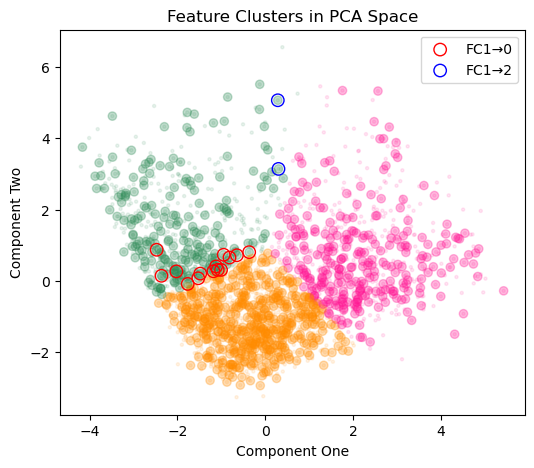

In [86]:
#initialize the figure
plt.figure(figsize=(6,5))

#plot the background points -- all of the galaxy data in PCA space
plt.scatter(df['Comp1'], df['Comp2'], c=df['Feature Cluster'], cmap=cmap, s=5, alpha=0.1)

#plot the test sample that the model classified
plt.scatter(df_test['Comp1'], df_test['Comp2'], c=y_test, cmap=cmap, alpha=0.3)

#add the FC2 --> FC0 overlay (FC2 galaxies which were misclassified as FC0)
plt.scatter(df_test['Comp1'][df_test['FC1_to_0']],
            df_test['Comp2'][df_test['FC1_to_0']],
            facecolors='none', edgecolors='red', s=80, label='FC1→0')

#add the FC2 --> FC1 overlay (FC2 galaxies which were misclassified as FC1)
plt.scatter(df_test['Comp1'][df_test['FC1_to_2']],
            df_test['Comp2'][df_test['FC1_to_2']],
            facecolors='none', edgecolors='blue', s=80, label='FC1→2')

#add legend, axis labels, title.
plt.legend()
plt.xlabel('Component One')
plt.ylabel('Component Two')
plt.title('Feature Clusters in PCA Space')

plt.show()

We can also take a moment to visually inspect the distribution of points in each Feature Group. Compared with FC0 (orange) especially, FC1 *and* FC2 are less compact with respect to both of the PCA axes. Is this finding quantifiable? Yes, in fact.

One option is to calculate the average scatter of features relative to their mean, for all galaxies in each of the three Feature Groups (not only the test samples!). Here is some *pseudocode* to articulate the approach:

* For every Feature Group,
    * For every feature column in that Feature Group,
        * Calculate the mean feature value (create a row of averages with length `len(features)`)
    * For every galaxy in that Feature Group,
        * Calculate the difference between that galaxy's features and the corresponding means
        * Square the differences, yielding a Euclidean distance measurement from that galaxy to the k-means
          cluster centroid (in the actual N-dimensional feature space, not PCA space!)
        * Sum each of these terms, the final step in the equation $D^2 = (p_1 - q_1)^2 + (p_2 - q_2) + ...$
    * With the distance squared terms for every galaxy row, calculate the average (this is the mean square radius; the squaring is meant to more strongly penalize larger distances)

Once this block of code executes, we will have quantative representations of scatter to compare between the three Feature Groups! Note that the choice of Euclidean distance here is largely for...say it with me...internal consistency: since k-means clustering utilizes Euclidean distances, our scatter measures with utilize Euclidean distances.

In [87]:
#convert to numpy arrays so the indices line up
Xv = X.values
yv = y.values

scatter = {}

for k in [0,1,2]:
   

    Xk = Xv[yv == k]       #isolates table rows belonging to Feature Cluster k
                           #written as a numpy matrix. yay.
                           #rows (axis=0) are galaxies, columns (axis=1) are features
    
    mu = Xk.mean(axis=0)   #calculates the mean for all feature columns -- creates array of length len(Features)
                           #Xk.mean() calculates mean of ALL values in Xk
                           #Xk.mean(axis=1) calculates mean for every galaxy row
            
    intercluster_distances = np.sum((Xk - mu)**2, axis=1) #axis=1 means that mu will be subtracted from
                                                          #every galaxy row feature-wise. those individual 
                                                          #row feature values will then be squared, 
                                                          #and finally summed.
                                                          #the result is one squared distance per galaxy.
            
    scatter[f'FC{k}'] = float(f'{np.mean(intercluster_distances):.3f}')   #find average scatter in features.
                                                        #np.mean then calculates the mean squared distance for
                                                        #all of the galaxies in the Feature Group.

In [88]:
scatter

{'FC0': 1.713, 'FC1': 3.637, 'FC2': 3.266}

This finding reinforces what the raincloud plots convey: systematically higher scatter in FC2. Indeed, while the figure directly comparing the input features for each Feature Group showed nearly invisible 68% confidence intervals on the median, the raincloud plots indicate that there is typically more intrinsic spread in FC2 morphologies - especially in Sersic indices, size ratios, and colors (note that the latter two, for which the 68% confidence intervals were much larger, were not involved in the ML model). 

We do observe such trends as a lower median size ratio and higher [NUV-r] color among FC2 galaxies; however, the spread of size ratios is high and the peak of the [NUV-r] distribution is in line with those of FC1 and FC0: systematically higher scatter in FC2. 

As we found in the previous section, k-means clustering created a Feature Group (FC2) that happens to harbor the highest fraction of Virgo cluster galaxies and the lowest fraction of field/isolated galaxies of the Feature Groups. Galaxy evolution literature shows that galaxies in high density environments tend to undergo significant morphology transformations (e.g., morphology-density relation; Dressler+1980) due to various galaxy-galaxy and galaxy-environment mechanisms. This, coupled with the Virgo Cluster being relatively young, irregular, and low-mass, is broadly consistent with a diversity of galaxy shapes and sizes among our cluster galaxies...despite trending toward lower size ratios, redder [NUV-r], and more early-type Sersic indices. 

## Measuring the Robustness of K-means Feature Groups [k=2-10]

### Up until now, we have favored k = 3 as a modeling choice. This section will explore whether some quantitative analysis also justifies the choice.

#### A. Random Forest Classification

##### Just as with the k=3 case above, I perform k-means clustering for the k=2-10 cases and evaluate how well a consistent random forest classification algorithm can determine the Feature Group assignments. Using my trusty script, I can automate this process rather efficiently.

In [98]:
run_rfc_comparison(df, k_list=[2,3,4,5])

####################

k = 2
              precision    recall  f1-score   support

           0      0.983     0.986     0.984       345
           1      0.992     0.990     0.991       621

    accuracy                          0.989       966
   macro avg      0.987     0.988     0.988       966
weighted avg      0.989     0.989     0.989       966


[[340   5]
 [  6 615]]

####################
####################

k = 3
              precision    recall  f1-score   support

           0      0.971     0.979     0.975       481
           1      0.927     0.948     0.937       213
           2      0.966     0.934     0.950       272

    accuracy                          0.960       966
   macro avg      0.955     0.954     0.954       966
weighted avg      0.960     0.960     0.960       966


[[471   6   4]
 [  6 202   5]
 [  8  10 254]]

####################
####################

k = 4
              precision    recall  f1-score   support

           0      0.968     0.970     

#### B. Adjusted Rand Index

In [101]:
feature_list = ['CRE_g', 'CRE_r','CRE_W1-fixBA',#,'CRE_W3-fixBA',
                  'CN_g', 'CN_r', 'CN_W1-fixBA']#, 'CN_W3-fixBA']
X = df[feature_list]

In [103]:
ari_k2 = ari_across_seeds(X, k=2, n_runs=100)
ari_k3 = ari_across_seeds(X, k=3, n_runs=100)
ari_k4 = ari_across_seeds(X, k=4, n_runs=100)
ari_k5 = ari_across_seeds(X, k=5, n_runs=100)
ari_k6 = ari_across_seeds(X, k=6, n_runs=100)
ari_k7 = ari_across_seeds(X, k=7, n_runs=100)
#ari_k10 = ari_across_seeds(X, k=10, n_runs=50)

print("k=2 ARI:  mean =", f'{ari_k2.mean():.4f}', " std =", f'{ari_k2.std():.4f}')
print("k=3 ARI:  mean =", f'{ari_k3.mean():.4f}', " std =", f'{ari_k3.std():.4f}')
print("k=4 ARI:  mean =", f'{ari_k4.mean():.4f}', " std =", f'{ari_k4.std():.4f}')
print("k=5 ARI:  mean =", f'{ari_k5.mean():.4f}', " std =", f'{ari_k5.std():.4f}')
print("k=6 ARI:  mean =", f'{ari_k6.mean():.4f}', " std =", f'{ari_k6.std():.4f}')
print("k=7 ARI:  mean =", f'{ari_k7.mean():.4f}', " std =", f'{ari_k7.std():.4f}')
#print("k=10 ARI: mean =", f'{ari_k10.mean():.4f}', " std =", f'{ari_k10.std():.4f}')

k=2 ARI:  mean = 0.9281  std = 0.2457
k=3 ARI:  mean = 0.9991  std = 0.0009
k=4 ARI:  mean = 0.6418  std = 0.2424
k=5 ARI:  mean = 0.6610  std = 0.2473
k=6 ARI:  mean = 0.8943  std = 0.1316
k=7 ARI:  mean = 0.7286  std = 0.1479


## HDBSCAN Run (Archived)

HDBSCAN differs from the more Euclidean k-means clustering in that it looks for localized, **discrete** overdensities in feature space. While k-means will force partitions even if they are not physically meaningful, HDBSCAN will not *invent* clusters and performs best when there are potent density contrasts in the data. Also unique to HDBSCAN is that the model will identify its own *cloud* of noisy data, which is analogous to the algorithm saying "idk what to do with these."

HDBSCAN uses the following hyperparameters:
* Minimum cluster size: smallest valid cluster size
* Minimum samples: higher value means smoother landscape and fewer small pockets of dense feature clusters)
* Metric: how the distances between points are calculated; Canberra gives more weight to small distances
* Cluster selection method: captures finer variations that eom (excess of mass) would merge into a single feature clusters

Although galaxy morphologies are indeed not discrete properties, I try HDBSCAN to determine how many unique Feature Groups it might identify without requiring the model to conform to the user's k preference. 

I did write a function in an effort to optimize these hyperparameters. The approach, called Density-Based Clustering Validation (DBCV), outputs a metric to assess the quality of the defined clusters with some configuration of hyperparameters - not unlike the elbow and silhouette methods for k-means clustering. Funnily enough, even the "best" DBCV score for my galaxy data is negative, indicating that my multi-dimensional morphology parameter space is continuous. 

In other words, there are no robust pockets of local density and HDBSCAN categories most galaxies as noise.

---

I instead selected hyperparameters such that the output vaguely resembled the k-means Feature Groups. I keep the results here as a self-serving reference more so than an informative section.

In [104]:
from hdbscan_pipeline import run_hdbscan

NOTE: be sure to edit galfit_parameters.py so parameters are to your liking!

USING THESE FEATURES: ['CRE_g', 'CRE_r', 'CRE_W1-fixBA', 'CN_g', 'CN_r', 'CN_W1-fixBA']

Applying the following completeness limits: logMstar > 8.06, logSFR > None
###################################################################################
Removed 3914/6780 galaxies with GALFIT, completeness limit, and PHOT quality flags.
###################################################################################


A copy of the scaled galaxy features was written to data/hdb_feature_data.csv!

A summary of feature cluster median properties saved to 
/Users/k215c316/github/machine-learning/galaxy_feature_clustering/data/hdbscan_median_features.csv:

5 clusters


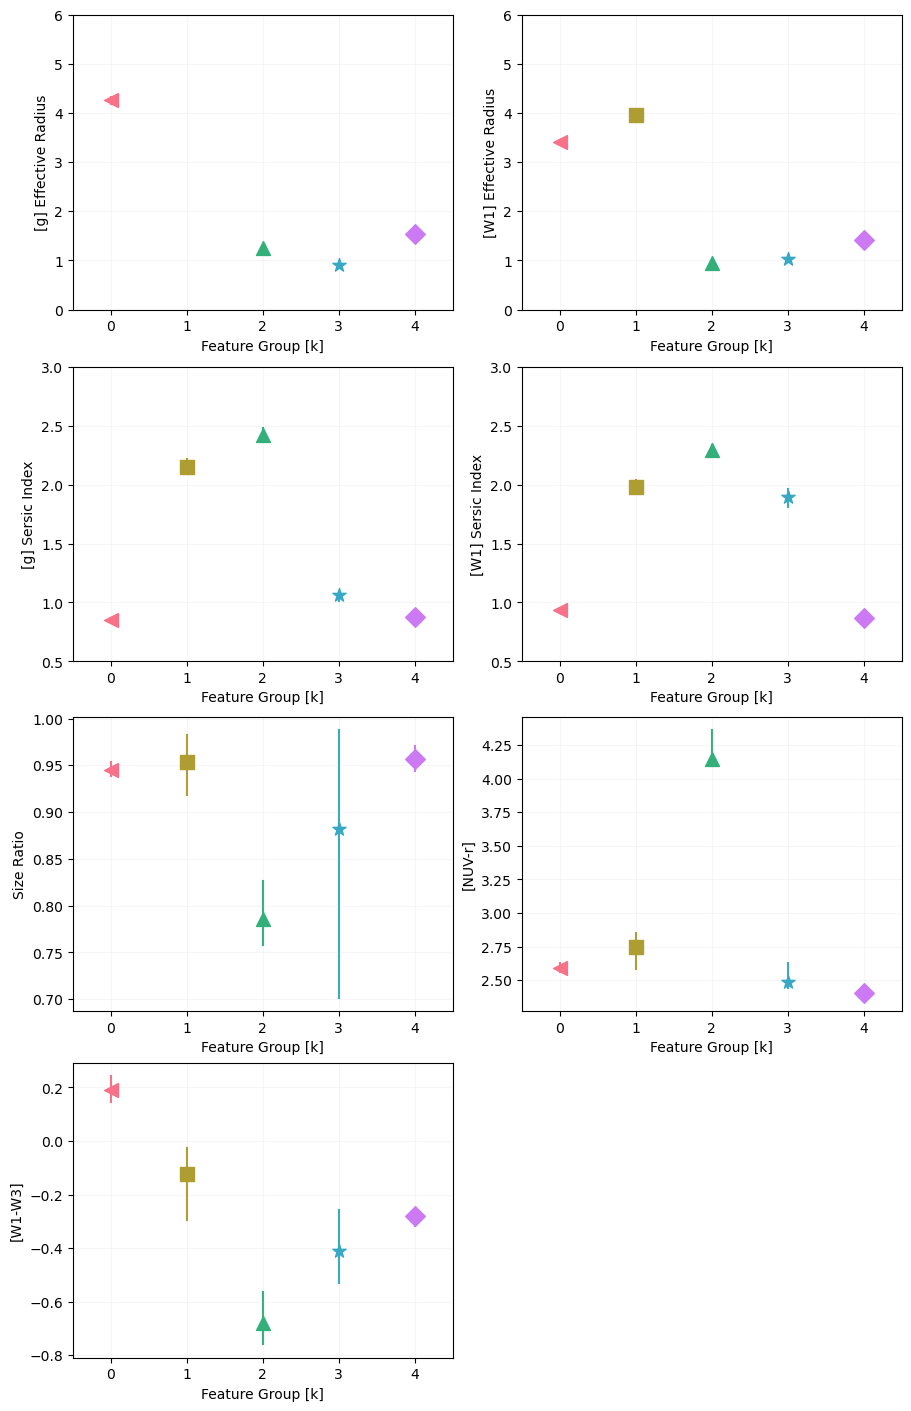

5 clusters


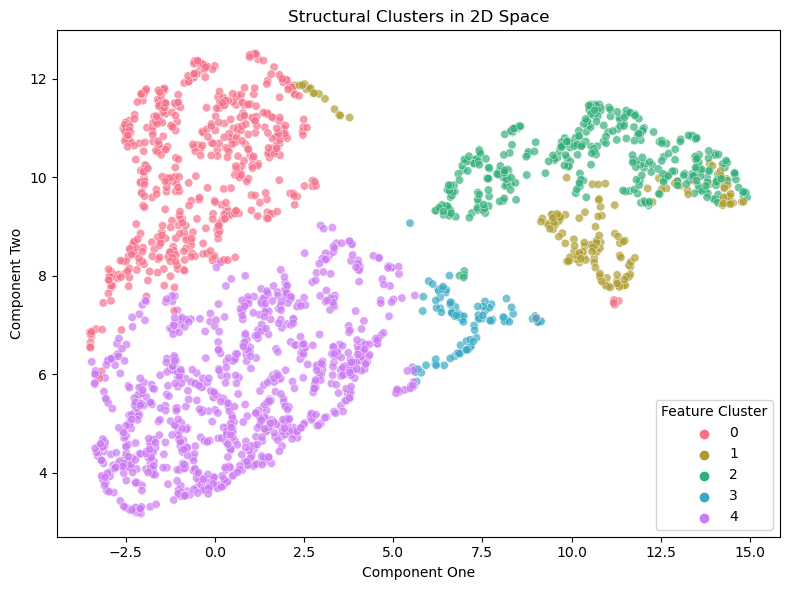

5 clusters


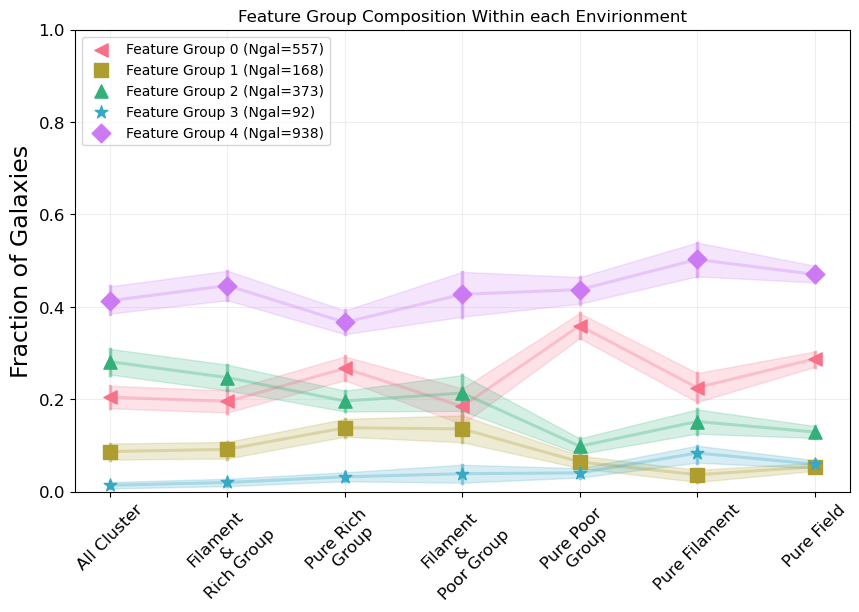

5 clusters


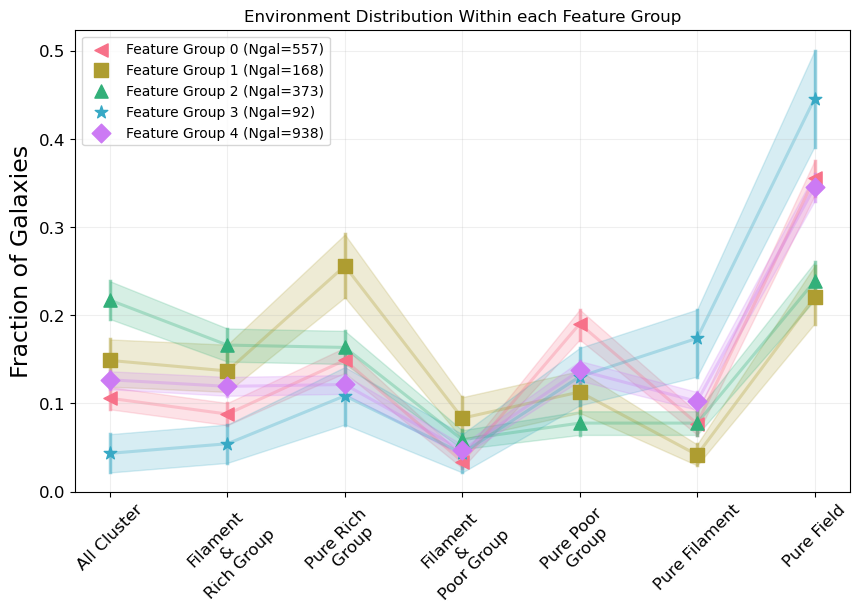

5 clusters


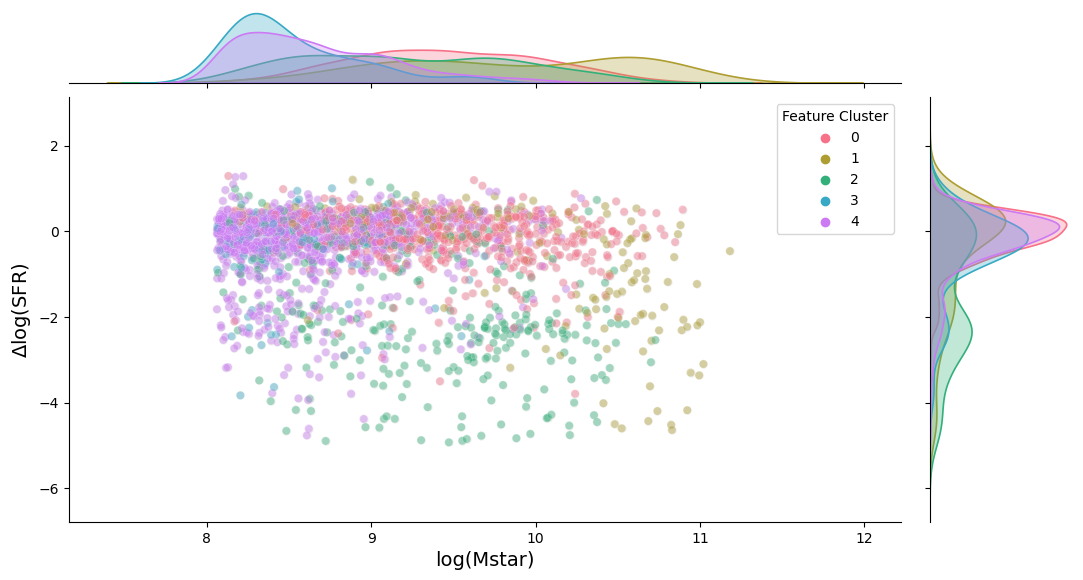

In [106]:
import warnings
warnings.filterwarnings("ignore")

df_scaled = run_hdbscan(colors=False)

## Testbed / Sandbox

In [77]:
from scipy.stats import ks_2samp

def mass_controlled_comparison(
    df,
    feature_col,
    mass_col='logmstar',
    cluster_col='Feature Cluster',
    group_a=1,          # e.g. green
    group_b=2,          # e.g. pink
    mass_bins=None,
    min_per_bin=10,
):
    """
    Compare feature distributions between two Feature Groups
    within stellar-mass bins.

    Returns a summary table.
    """

    if mass_bins is None:
        mass_bins = np.arange(
            df[mass_col].min(),
            df[mass_col].max() + 0.3,
            0.3
        )

    rows = []

    for lo, hi in zip(mass_bins[:-1], mass_bins[1:]):
        bin_df = df[(df[mass_col] >= lo) & (df[mass_col] < hi)]

        a = bin_df[bin_df[cluster_col] == group_a][feature_col]
        b = bin_df[bin_df[cluster_col] == group_b][feature_col]

        if (len(a) < min_per_bin) or (len(b) < min_per_bin):
            continue

        ks_stat, ks_p = ks_2samp(a, b)

        rows.append({
            'logMstar_lo': lo,
            'logMstar_hi': hi,
            'N_a': len(a),
            'N_b': len(b),
            'median_a': np.median(a),
            'median_b': np.median(b),
            'delta_median': np.median(b) - np.median(a),
            'KS_pvalue': ks_p,
        })

    return pd.DataFrame(rows)


In [92]:
res_nuvr = mass_controlled_comparison(
    df,
    feature_col='NUV_r',
    group_a=1,   
    group_b=0    
)

res_w1w3 = mass_controlled_comparison(
    df,
    feature_col='W1_W3',
    group_a=1,
    group_b=0
)

res_nser = mass_controlled_comparison(
    df,
    feature_col='CN_g_unscaled',
    group_a=1,
    group_b=0
)


In [93]:
res_nuvr

,logMstar_lo,logMstar_hi,N_a,N_b,median_a,median_b,delta_median,KS_pvalue
0,8.661523,8.961523,16,97,1.869121,2.210748,0.341627,0.001084
1,8.961523,9.261523,63,123,2.257780,2.337189,0.079409,0.127041
2,9.261523,9.561523,76,61,2.407461,2.546225,0.138764,0.003953
3,9.561523,9.861523,68,33,2.599739,2.721616,0.121877,0.182856
4,9.861523,10.161523,55,22,2.956630,3.040362,0.083731,0.749053


In [94]:
res_w1w3

,logMstar_lo,logMstar_hi,N_a,N_b,median_a,median_b,delta_median,KS_pvalue
0,8.661523,8.961523,16,97,-0.372165,-0.175716,0.196449,1.989529e-02
1,8.961523,9.261523,63,123,-0.298098,0.071071,0.369169,3.769631e-07
2,9.261523,9.561523,76,61,0.082974,0.614157,0.531183,1.239254e-09
3,9.561523,9.861523,68,33,0.444283,1.083995,0.639712,3.168363e-08
4,9.861523,10.161523,55,22,0.674975,1.261223,0.586248,4.710558e-09


In [26]:
vcosmic0=df['Vcosmic'][df['Feature Cluster']==0]
vcosmic1=df['Vcosmic'][df['Feature Cluster']==1]
vcosmic2=df['Vcosmic'][df['Feature Cluster']==2]

dsfr0=df['delta_logsfr'][df['Feature Cluster']==0]
dsfr1=df['delta_logsfr'][df['Feature Cluster']==1]
dsfr2=df['delta_logsfr'][df['Feature Cluster']==2]

sfr0=df['logsfr'][df['Feature Cluster']==0]
sfr1=df['logsfr'][df['Feature Cluster']==1]
sfr2=df['logsfr'][df['Feature Cluster']==2]

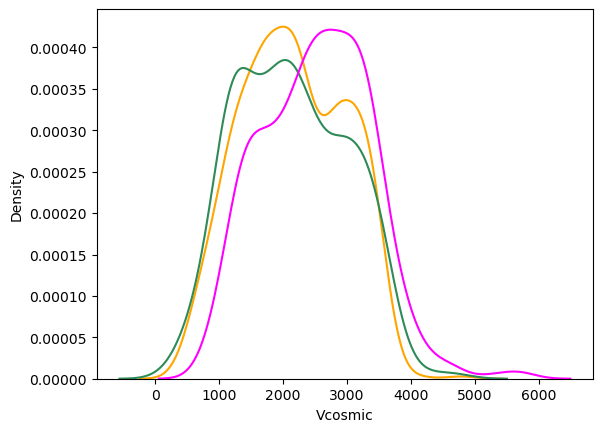

In [15]:
import seaborn as sns
sns.kdeplot(vcosmic0, color= 'orange') 
sns.kdeplot (vcosmic1, color= 'seagreen')
sns.kdeplot (vcosmic2, color='magenta')
#plt.title('W1, optical morphologies')
plt.show()

Text(0, 0.5, '$\\Delta$logSFR')

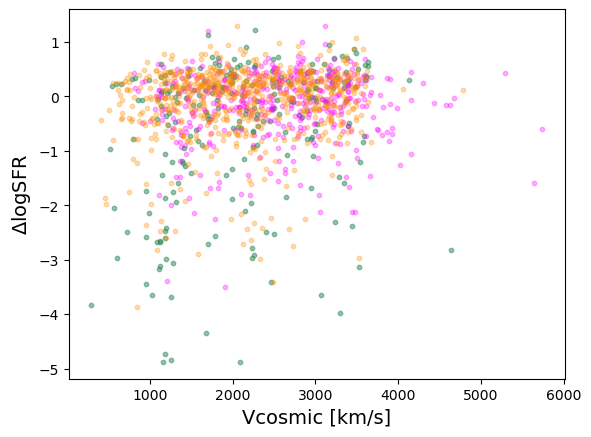

In [23]:
plt.scatter(vcosmic1,dsfr1,color='seagreen',s=10,alpha=0.5)
plt.scatter(vcosmic2,dsfr2,color='magenta',s=10,alpha=0.3)
plt.scatter(vcosmic0,dsfr0,color='darkorange',s=10,alpha=0.3)

plt.xlabel('Vcosmic [km/s]',fontsize=14)
plt.ylabel(r'$\Delta$logSFR',fontsize=14)

Text(0, 0.5, 'logSFR')

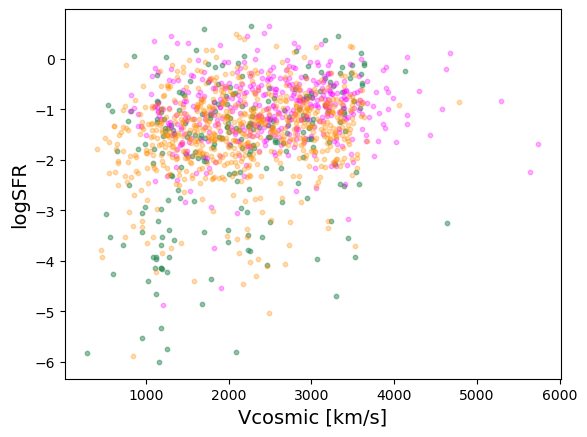

In [29]:
plt.scatter(vcosmic1,sfr1,color='seagreen',s=10,alpha=0.5)
plt.scatter(vcosmic2,sfr2,color='magenta',s=10,alpha=0.3)
plt.scatter(vcosmic0,sfr0,color='darkorange',s=10,alpha=0.3)

plt.xlabel('Vcosmic [km/s]',fontsize=14)
plt.ylabel('logSFR',fontsize=14)

In [41]:
np.sort(df['Vcosmic'][flag])[int(len(df['Vcosmic'][flag])*0.8)]

2640.631388969997

In [40]:
flag=df['Vcosmic']<3100

## HIERARCHICAL CLUSTERING

In [5]:
#fg2, when the algorithm is run on the mass- and sfr-complete sample, has 234 galaxies.
#let's try to apply k-means clustering...
#will also have to check whether similar patterns occur with fg1 and fg0, assumming there *is* a pattern.

from plotting_utils import *

In [6]:
#save original df, just in case.
df_og = df.copy()

In [7]:
df = df_og.copy()

In [8]:
fg2_data = df.copy()[df['Feature Cluster']==2]

feature_list = ['CRE_g', 'CRE_r','CRE_W1-fixBA','CRE_W3-fixBA',
                'CN_g', 'CN_r', 'CN_W1-fixBA', 'CN_W3-fixBA',
                'CRE_W2', 'CRE_W2']

In [9]:
fg2 = run1_kmeans(fg2_data, feature_list, k=2, n_init=400, random_state=42)

In [10]:
#change 0 to 2, 1 to 3 (so the labels do not conflict with existing 0, 1 FGs)
#add new labels (with .loc()?) to df
#plot...evaluate...the usual.

fg_col_edit = fg2.copy()['Feature Cluster'].replace({0: 2,
                                                     1: 3})

fg2['Feature Cluster']=fg_col_edit

df['Feature Cluster'].update(fg2['Feature Cluster'])

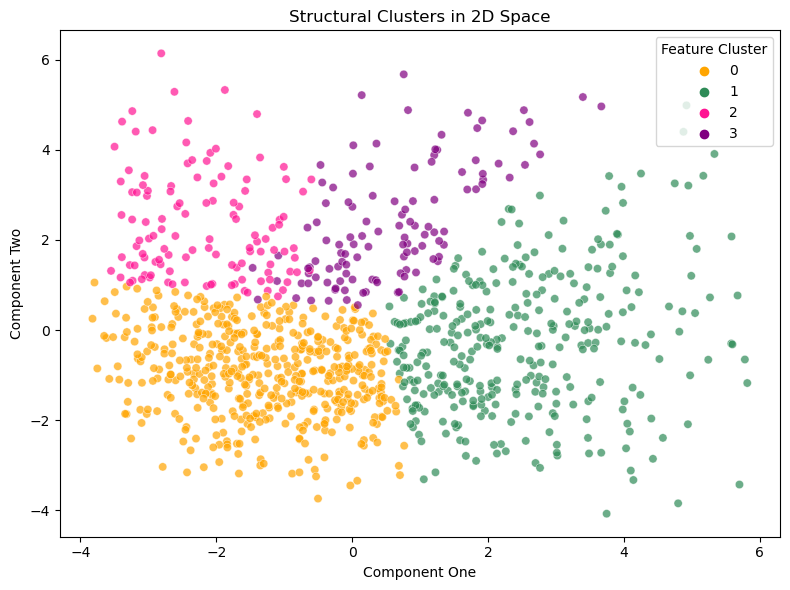

In [11]:
#sort the unique feature groups numerically
unique_clusters = sorted(df['Feature Cluster'].unique())

x = 'Comp1'
y = 'Comp2'

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x=x, y=y, hue='Feature Cluster', 
                    palette=['orange','seagreen','deeppink','purple'], alpha=0.7, edgecolor='w', linewidth=0.4)

plt.xlabel('Component One')
plt.ylabel('Component Two')

plt.title(f'Structural Clusters in 2D Space')
plt.tight_layout()
plt.show()


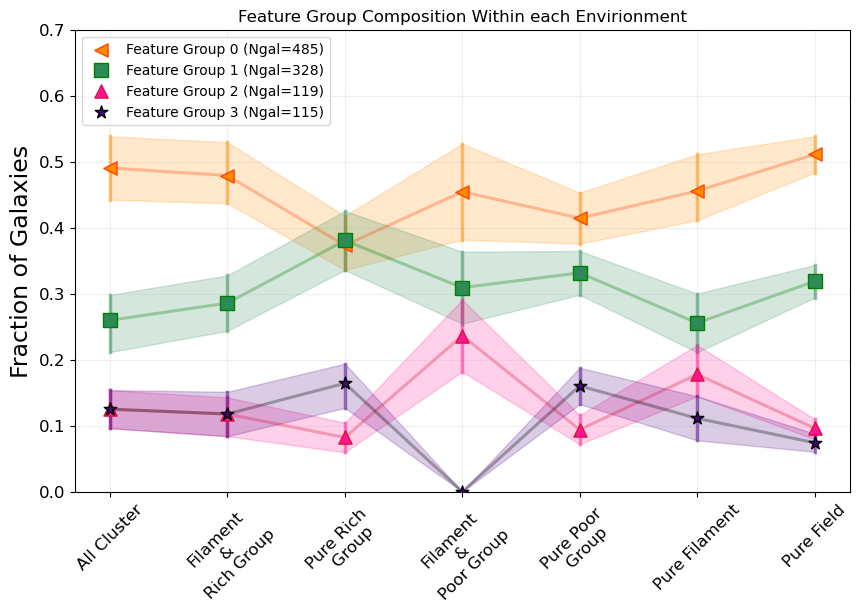

In [12]:
plot_env_fraction(df, main_only=False, envfrac=False, envcomp=True)

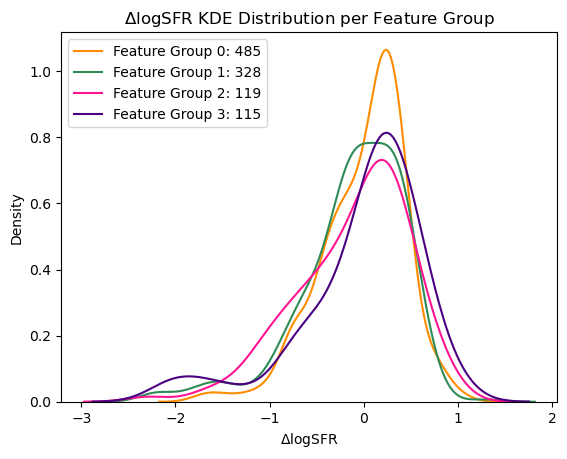

--------------------
ks stat (FG0 & FG1): 0.11247799849132512
p-value (FG0 & FG1): 0.012794497462791106
--------------------
--------------------
ks stat (FG0 & FG2): 0.12092177077016374
p-value (FG0 & FG2): 0.11106782559410222
--------------------
--------------------
ks stat (FG0 & FG3): 0.10237561631555356
p-value (FG0 & FG3): 0.26310545948507214
--------------------
--------------------
ks stat (FG1 & FG2): 0.0663558106169297
p-value (FG1 & FG2): 0.8062366601361197
--------------------
--------------------
ks stat (FG1 & FG3): 0.20151113467656415
p-value (FG1 & FG3): 0.001635056914817435
--------------------
--------------------
ks stat (FG2 & FG3): 0.15432955791012057
p-value (FG2 & FG3): 0.1069426177496724
--------------------


In [13]:
plot_dSFR_KDEs(df)

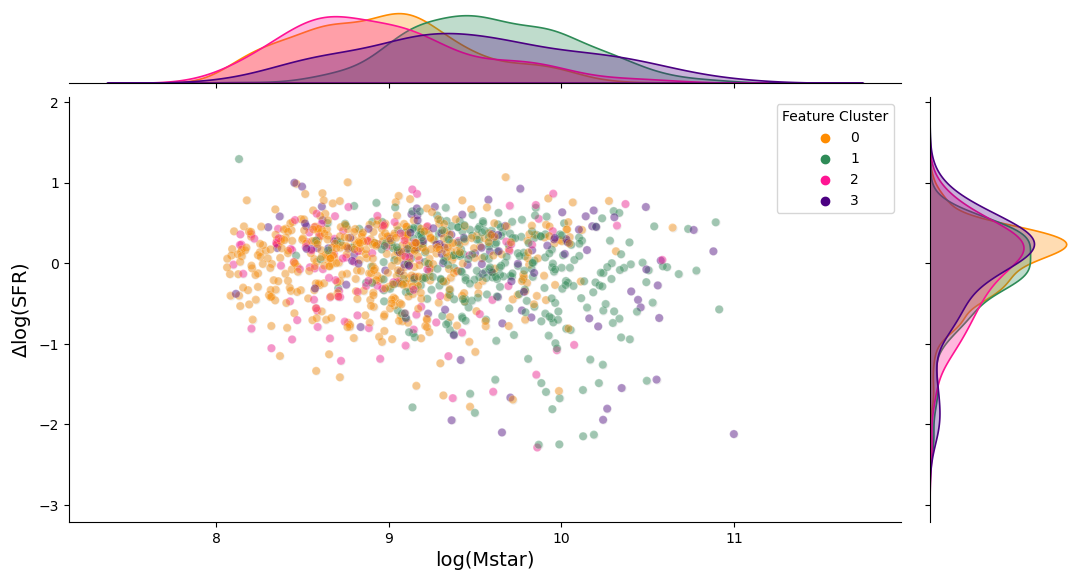

In [14]:
plot_sfrmstar(df)

In [15]:
from table_utils import create_median_table
meds = pd.DataFrame(create_median_table(df, feature_list))

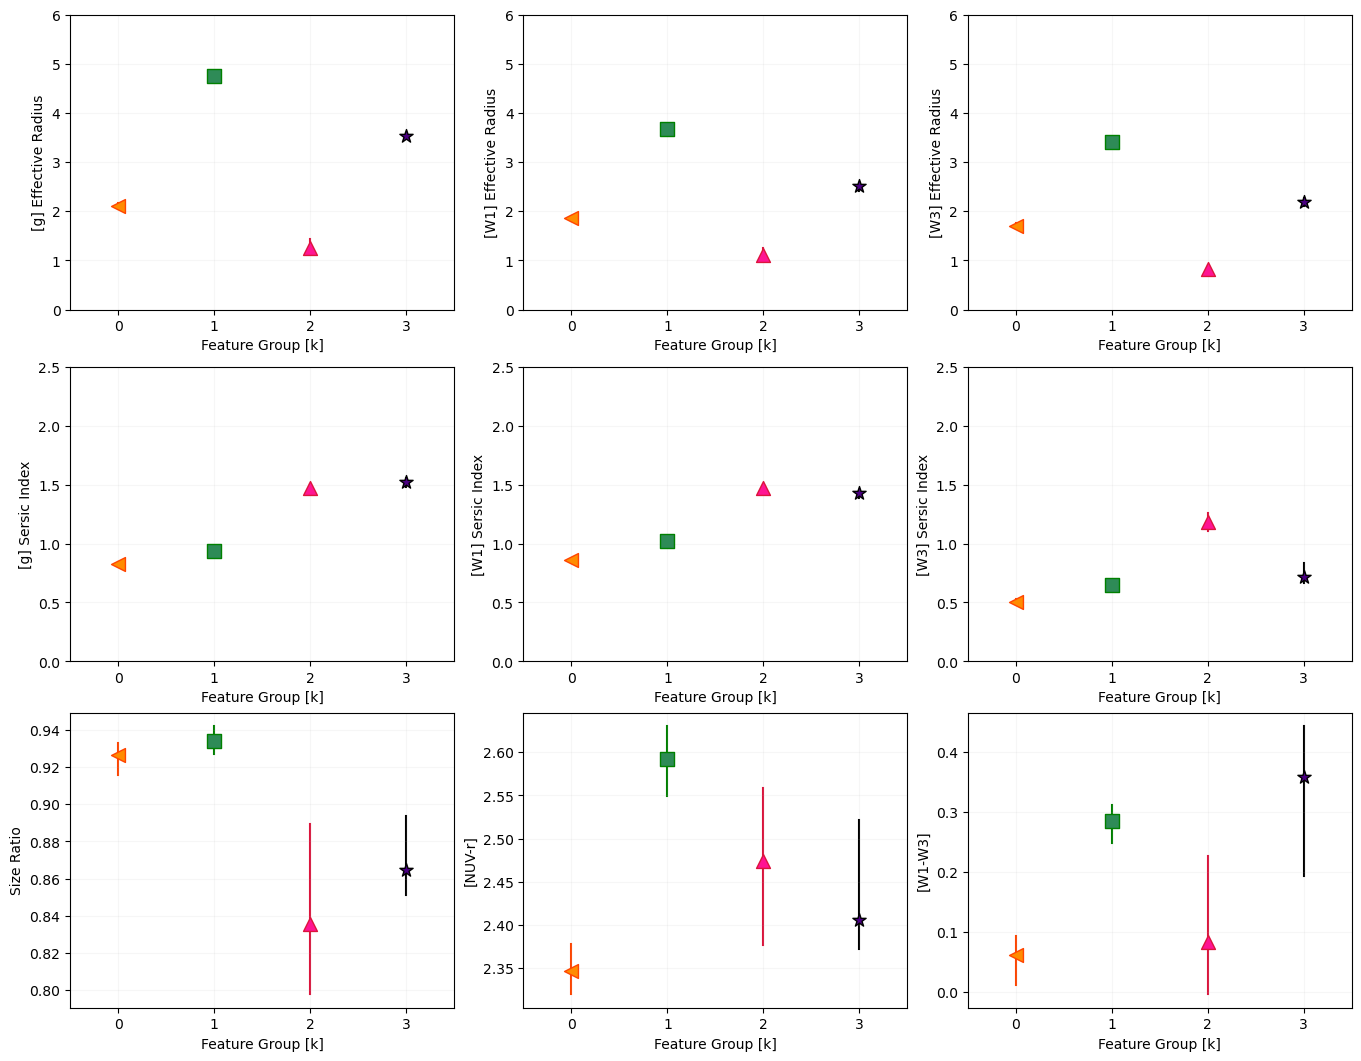

In [16]:
plot_group_features(meds, layout_dict= {(0, 0): 'CRE_g_unscaled',
                                        (0, 1): 'CRE_W1-fixBA_unscaled',
                                        (0, 2): 'CRE_W3-fixBA_unscaled',
                                        (1, 0): 'CN_g_unscaled',
                                        (1, 1): 'CN_W1-fixBA_unscaled',
                                        (1, 2): 'CN_W3-fixBA_unscaled',
                                        (2, 0): 'Size Ratio',
                                        (2, 1): 'NUV_r',
                                        (2, 2): 'W1_W3'})
